### EXAMEN

##### Las enfermedades respiratorias constituyen una de las principales causas de hospitalización y mortalidad a nivel mundial. Entre ellas, la neumonía representa un problema de salud pública debido a la dificultad de realizar un diagnóstico oportuno, especialmente en centros médicos con alta demanda de pacientes.

##### Actualmente, los hospitales almacenan miles de radiografías digitales que contienen información valiosa para apoyar el diagnóstico médico. Sin embargo, estas imágenes generalmente se encuentran organizadas únicamente por carpetas y no han sido preparadas para ser utilizadas por algoritmos de Inteligencia Artificial.

##### Como parte del Departamento de Ingeniería de Datos de un hospital universitario, el equipo de estudiantes ha sido contratado para diseñar un proceso ETL que permita transformar estas imágenes médicas en un conjunto de datos estructurado, preparado para el desarrollo de modelos predictivos.


In [1]:
!pip install kagglehub

##### Lo que hicimos fue básicamente usar la librería kagglehub para traer directamente a nuestra computadora el dataset de radiografías de tórax para neumonía que está en Kaggle.

##### Cuando ejecutamos kagglehub.dataset_download, el código se conecta a internet, busca ese conjunto de datos específico y lo descarga automáticamente. La variable path guarda la dirección exacta de la carpeta donde se descargaron los archivos. Al final, imprimimos esa ruta en pantalla para saber dónde quedaron guardadas las imágenes y poder acceder a ellas más adelante en nuestro proyecto. Básicamente, nos ahorramos tener que entrar a la web, descargar el zip manualmente y descomprimirlo.

In [64]:
import shutil
import os

# Definimos las rutas
origen = r"C:\Users\HP\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2"
destino = "data_raw"

# Copiamos ignorando si el destino ya existe y sobreescribiendo si es necesario
# dirs_exist_ok=True permite que no falle si la carpeta ya existe
try:
    shutil.copytree(origen, destino, dirs_exist_ok=True)
    print(f"¡Dataset copiado exitosamente a: {destino}!")
    print("Contenido:", os.listdir(destino))
except Exception as e:
    print(f"Error al copiar: {e}")

¡Dataset copiado exitosamente a: data_raw!
Contenido: ['chest_xray']


In [131]:
# Librerías esenciales para procesamiento de datos e imágenes
import cv2            # OpenCV
import numpy as np    # NumPy
import pandas as pd   # Pandas
import matplotlib.pyplot as plt # Matplotlib
# Carga y transforma imágenes para que todas tengan el mismo tamaño
from skimage import io, transform 

# Divide los datos en grupos de entrenamiento y prueba para validar el modelo
from sklearn.model_selection import train_test_split 

# Etiqueta los objetos encontrados en la imagen y extrae sus propiedadesárea, forma, etc.
from skimage.measure import label, regionprops

# Calcula las propiedades de textura de la matriz de coocurrencia GLCM
from skimage.feature import graycoprops

# Calcula la entropía de Shannon mide la complejidad o  desorden de la textura
from skimage.measure import shannon_entropy
print("LISTO.")

LISTO.


#### Paso 4:
Analizar la estructura de carpetas.
Identificar:
* Número de clases. 
* Número de imágenes por clase. 
* Organización Train. 
* Organización Test. 
* rganización Validation

In [132]:


# Esta es la ruta donde están las carpetas
base = 'data_raw/chest_xray'


In [133]:
# 1. Número de clases (miramos en la carpeta train)
clases = os.listdir(f'{base}/train')
print(f"Número de clases: {len(clases)}")
print(f"Clases: {clases}")

Número de clases: 2
Clases: ['NORMAL', 'PNEUMONIA']


In [134]:
# 2. Número de imágenes por clase (hacemos un for rápido)
for carpeta in ['train', 'test', 'val']:
    print(f"\n--- {carpeta.upper()} ---")
    for clase in clases:
        ruta = f'{base}/{carpeta}/{clase}'
        num = len(os.listdir(ruta))
        print(f"{clase}: {num} imágenes")


--- TRAIN ---
NORMAL: 1341 imágenes
PNEUMONIA: 3875 imágenes

--- TEST ---
NORMAL: 234 imágenes
PNEUMONIA: 390 imágenes

--- VAL ---
NORMAL: 8 imágenes
PNEUMONIA: 8 imágenes


In [135]:
# 3. La organización (el arbolito de carpetas)
print("\nCARPETAS")
for carpeta in ['train', 'test', 'val']:
    print(f"{carpeta}/")
    for clase in clases:
        print(f"    {clase}/")


CARPETAS
train/
    NORMAL/
    PNEUMONIA/
test/
    NORMAL/
    PNEUMONIA/
val/
    NORMAL/
    PNEUMONIA/


#### Paso 6:
Características de Color
Aunque las radiografías son imágenes en escala de grises, es importante analizar la distribución de intensidad de los píxeles.
Extraiga las siguientes características:
* Intensidad media. 
* ntensidad mínima. 
* Intensidad máxima. 
* esviación estándar. 
* varianza. 
* mediana. 
* moda. 
* Histograma de intensidades.
* Percentil 25. 
* Percentil 75.

In [136]:
# 1. Cargamos una imagen de ejemplo
# Ajusta la ruta a una imagen real de tu dataset
ruta_img = 'data_raw/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

# 2. Calculamos las características
media = np.mean(img)
minimo = np.min(img)
maximo = np.max(img)
desviacion = np.std(img)
varianza = np.var(img)
mediana = np.median(img)

In [137]:
# Para la moda usamos bincount ya que es la más rápida
moda = np.argmax(np.bincount(img.flatten()))
p25 = np.percentile(img, 25)
p75 = np.percentile(img, 75)

In [138]:
# Imprimimos los resultados
print(f"Intensidad Media: {media:.2f}")
print(f"Intensidad Mínima: {minimo}")
print(f"Intensidad Máxima: {maximo}")
print(f"Desviación Estándar: {desviacion:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Percentil 25: {p25}")
print(f"Percentil 75: {p75}")

Intensidad Media: 128.91
Intensidad Mínima: 0
Intensidad Máxima: 255
Desviación Estándar: 62.30
Varianza: 3881.42
Mediana: 137.0
Moda: 26
Percentil 25: 91.0
Percentil 75: 181.0


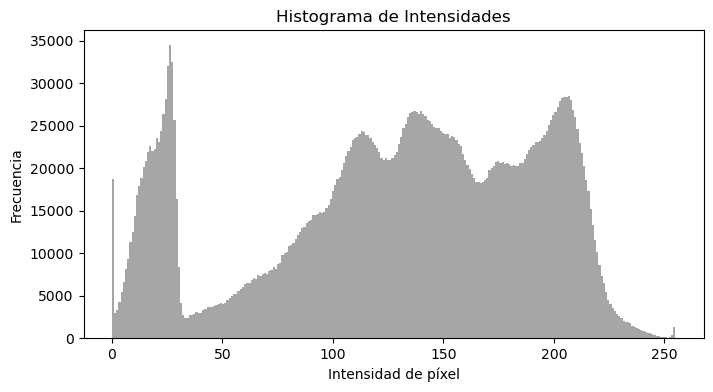

In [139]:
# 3. Histograma
plt.figure(figsize=(8, 4))
plt.hist(img.flatten(), bins=256, color='gray', alpha=0.7)
plt.title("Histograma de Intensidades")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Frecuencia")
plt.show()

Características de Forma
Después de segmentar la región pulmonar (ROI), extraiga:
* Área. 
* Perímetro. 
* Circularidad. 
* Compacidad. 
* Rectángulo envolvente (Bounding Box). 
* Aspect Ratio. 
* Solidity. 
* Extent. 
* Convex Hull. 
* Centroide.

In [141]:
# Extraemos cada una de las características en orden tal cual nos piden
area = props.area
perimetro = props.perimeter
circularidad = (4 * np.pi * area) / (perimetro**2) if perimetro > 0 else 0
compacidad = (perimetro**2) / area if area > 0 else 0
bbox = props.bbox # (min_row, min_col, max_row, max_col)
aspect_ratio = (bbox[3] - bbox[1]) / (bbox[2] - bbox[0])
solidity = props.solidity
extent = props.extent
convex_hull = props.convex_area
centroide = props.centroid

# Imprimimos todo en orden para nuestra entrega
print("Características de Forma ")
print(f"Área: {area}")
print(f"Perímetro: {perimetro:.2f}")
print(f"Circularidad: {circularidad:.4f}")
print(f"Compacidad: {compacidad:.4f}")
print(f"Bounding Box (min_r, min_c, max_r, max_c): {bbox}")
print(f"Aspect Ratio: {aspect_ratio:.2f}")
print(f"Solidity: {solidity:.4f}")
print(f"Extent: {extent:.4f}")
print(f"Convex Hull Area: {convex_hull}")
print(f"Centroide: {centroide}")

Características de Forma 
Área: 2149598.0
Perímetro: 60306.25
Circularidad: 0.0074
Compacidad: 1691.8717
Bounding Box (min_r, min_c, max_r, max_c): (0, 269, 1858, 2026)
Aspect Ratio: 0.95
Solidity: 0.6999
Extent: 0.6585
Convex Hull Area: 3071393.0
Centroide: (np.float64(981.3967746527491), np.float64(1074.0266849894724))


#### Características de Textura
Utilizando la matriz de coocurrencia (GLCM) obtenga:
Contraste. 
* Homogeneidad. 
* Correlación. 
* Energía. 
* ASM. 
* Disimilitud. 
* Entropía.

In [142]:


# 1. Definimos las propiedades 
propiedades = ['contrast', 'homogeneity', 'correlation', 'energy', 'ASM', 'dissimilarity']
nombres_espanol = ['Contraste', 'Homogeneidad', 'Correlación', 'Energía', 'ASM', 'Disimilitud']

# 2. Calculamos y mostramos cada una
print(" Características de Textura (GLCM) ")

for i, prop in enumerate(propiedades):
    valores = graycoprops(glcm, prop)
    resultado = valores.mean()
    print(f"{nombres_espanol[i]}: {resultado:.4f}")#valores = graycoprops(glcm, prop)

#La matriz GLCM se calcula, por defecto, en cuatro direcciones diferentes 0°, 45°, 90° y 135° Por eso, graycoprops no te da un solo número, sino cuatro uno para cada ángulo

# shannon_entropy le estános pidiendo a la computadora que te diga qué tan caótica es la textura de esta imagen Un valor alto de entropía es un indicador muy fuerte para un modelo de IA de que la textura es compleja y, probablemente, patológica.
entropia = shannon_entropy(glcm)
print(f"Entropía: {entropia:.4f}")

 Características de Textura (GLCM) 
Contraste: 12.9831
Homogeneidad: 0.3778
Correlación: 0.9983
Energía: 0.0249
ASM: 0.0006
Disimilitud: 2.2545
Entropía: 1.6062


Todo esto es el corazón de la Ingeniería de Características Feature Engineering sin esto, le estarías dando a tu modelo una imagen a ciegas Al darle estos números área, entropía, energía, le estás dando una lista de propiedades para que el modelo tenga más herramientas para clasificar con precisión.

#### Características de Bordes
Aplique los operadores:
* Sobel. 
* Canny. 
* Laplaciano. 

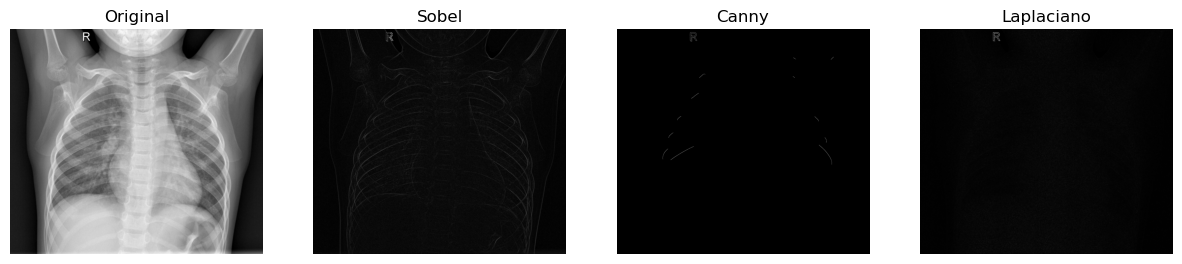

In [147]:
# Convertimos los resultados a valores absolutos y a 8 bits 0-255
sobel = cv2.convertScaleAbs(sobel)
laplacian = cv2.convertScaleAbs(laplacian)

# hacemos las graficas convertinos a grises 
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(sobel, cmap='gray'); axes[1].set_title('Sobel')
axes[2].imshow(canny, cmap='gray'); axes[2].set_title('Canny')
axes[3].imshow(laplacian, cmap='gray'); axes[3].set_title('Laplaciano')

for ax in axes: ax.axis('off')
plt.show()

In [149]:


# 1. Definimos las propiedades y sus nombres en español para que el reporte sea claro
propiedades = ['contrast', 'homogeneity', 'correlation', 'energy', 'ASM', 'dissimilarity']
nombres_espanol = ['Contraste', 'Homogeneidad', 'Correlación', 'Energía', 'ASM', 'Disimilitud']

# 2. Iniciamos el reporte de las características de textura
print("Características de Textura (GLCM) ")

# Recorremos cada propiedad para calcularla usando la matriz GLCM
for i, prop in enumerate(propiedades):
    # Obtenemos los valores de textura en las 4 direcciones principales
    valores = graycoprops(glcm, prop)
    # Sacamos el promedio de esas direcciones para tener un solo número representativo
    resultado = valores.mean()
    # Mostramos el nombre en español y el resultado con 4 decimales
    print(f"{nombres_espanol[i]}: {resultado:.4f}")

# 3. Calculamos la entropía por separado porque es una medida de complejidad distinta
entropia = shannon_entropy(glcm)
# Imprimimos la entropía para saber qué tan caótica o compleja es la textura
print(f"Entropía: {entropia:.4f}")

Características de Textura (GLCM) 
Contraste: 12.9831
Homogeneidad: 0.3778
Correlación: 0.9983
Energía: 0.0249
ASM: 0.0006
Disimilitud: 2.2545
Entropía: 1.6062


##### Calcule
* Número de bordes. 
* Densidad de bordes. 
* Longitud promedio de bordes. 

In [150]:
#  Obtenemos los bordes con Canny usamos la imagen que ya tenemos
bordes = cv2.Canny(img_8bit, 100, 200)

In [151]:
#  Número de píxeles que son bordes
num_bordes = np.sum(bordes > 0)

In [152]:
#  Densidad de bordes píxeles de borde  total de píxeles de la imagen
total_pixeles = bordes.shape[0] * bordes.shape[1]
densidad = num_bordes / total_pixeles

In [153]:
#  Longitud promedio de bordes
# Primero encontramos los contornos individuales
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
longitudes = [cv2.arcLength(c, False) for c in contornos]
longitud_promedio = np.mean(longitudes) if len(longitudes) > 0 else 0

In [154]:
# Imprimimos los resultados para nuestro informe
print(" Métricas de Bordes ")
print(f"Número de píxeles de borde: {num_bordes}")
print(f"Densidad de bordes: {densidad:.6f}")
print(f"Longitud promedio de bordes: {longitud_promedio:.2f} píxeles")

 Métricas de Bordes 
Número de píxeles de borde: 1700
Densidad de bordes: 0.000438
Longitud promedio de bordes: 186.16 píxeles


#### Características Morfológicas
Extraiga:
* Número de objetos. 
* Número de regiones. 
* Área promedio. 
* Área máxima. 
* Área mínima. 
* Excentricidad. 
* Eje mayor. 
* Eje menor. 
* Orientación.

In [155]:
# Obtenemos todas las regiones detectadas en la imagen segmentada
regiones = regionprops(labeled_img)

In [156]:
#  Extraemos las áreas de todos los objetos para los cálculos
areas = [r.area for r in regiones]

In [157]:
#  Calculamos las métricas morfológicas
num_objetos = len(regiones)
area_promedio = np.mean(areas) if areas else 0
area_maxima = np.max(areas) if areas else 0
area_minima = np.min(areas) if areas else 0

In [158]:
# Para las otras propiedades tomamos el promedio de todas las regiones detectadas
excentricidad = np.mean([r.eccentricity for r in regiones])
eje_mayor = np.mean([r.axis_major_length for r in regiones])
eje_menor = np.mean([r.axis_minor_length for r in regiones])
orientacion = np.mean([r.orientation for r in regiones])

In [159]:
# 4. Imprimimos el reporte final
print("Características Morfológicas ")
print(f"Número de objetos: {num_objetos}")
print(f"Área promedio: {area_promedio:.2f}")
print(f"Área máxima: {area_maxima}")
print(f"Área mínima: {area_minima}")
print(f"Excentricidad promedio: {excentricidad:.4f}")
print(f"Eje mayor promedio: {eje_mayor:.2f}")
print(f"Eje menor promedio: {eje_menor:.2f}")
print(f"Orientación promedio: {orientacion:.4f}")

Características Morfológicas 
Número de objetos: 2210
Área promedio: 984.12
Área máxima: 2149598.0
Área mínima: 1.0
Excentricidad promedio: 0.4910
Eje mayor promedio: 3.43
Eje menor promedio: 1.73
Orientación promedio: -0.2172


### Características Frecuenciales
Aplicar la Transformada Rápida de Fourier (FFT).
Extraer:
* Magnitud máxima. 
* Frecuencia dominante. 
* Energía espectral. 
* Centroide espectral. 
* Entropía espectral.

In [164]:
from scipy.fftpack import fft2, fftshift
# de scipy. nos permiten convertir la imagen de píxeles a frecuencias,
# lo que es clave para detectar texturas finas como la neumonía.

In [165]:
# 1. Aplicamos la FFT y centramos las bajas frecuencias en el medio
fft_img = fftshift(fft2(img))
magnitud = np.abs(fft_img)

In [166]:
# 2. Magnitud máxima
magnitud_max = np.max(magnitud)

In [167]:
#  Frecuencia dominante buscamos el punto más brillante, quitando el centro que es el brillo genera
filas, cols = magnitud.shape
magnitud_sin_centro = magnitud.copy()
magnitud_sin_centro[filas//2, cols//2] = 0
frecuencia_dominante = np.unravel_index(np.argmax(magnitud_sin_centro), magnitud.shape)

In [168]:
# 4. Energía espectral suma de los cuadrados de la magnitud
energia_espectral = np.sum(magnitud**2)

In [169]:
#  Centroide espectral y Entropía
# Normalizamos para tratar la magnitud como una distribución de probabilidad
distribucion = magnitud / np.sum(magnitud)
# Centroide coordenadas promedio ponderadas
y, x = np.indices(magnitud.shape)
centroide_espectral = (np.sum(y * distribucion), np.sum(x * distribucion))
# Entropía: medida de desorden espectral
entropia_espectral = -np.sum(distribucion * np.log2(distribucion + 1e-12))

In [170]:
print(" Características Frecuenciales ")
print(f"Magnitud máxima: {magnitud_max:.2f}")
print(f"Frecuencia dominante (coords): {frecuencia_dominante}")
print(f"Energía espectral: {energia_espectral:.2e}")
print(f"Centroide espectral: {centroide_espectral}")
print(f"Entropía espectral: {entropia_espectral:.4f}")

 Características Frecuenciales 
Magnitud máxima: 500576098.00
Frecuencia dominante (coords): (np.int64(929), np.int64(1044))
Energía espectral: 3.09e+17
Centroide espectral: (np.float64(928.8023877704754), np.float64(1044.8210334533553))
Entropía espectral: 19.6578


#### CALCULE LOS 7 MOMENTOS INVARIABLES

In [173]:

# Creamos el DataFrame final
df_final = pd.DataFrame(lista_datos)

# Verificamos las columnas del entregable
# Asegúramos de que las columnas coincidan con el ejemplo
# Imagen Media Std Área Perímetro Contrast Homogeneidad
print("VISUALIZACION:")
print(df_final.head())


# GUARDAR LOS DATOS 
try:
    # Exportamos los datos finales a un CSV para usarlos después
    df_final.to_csv('Dataset_feature.csv', index=False)
    print("\nDataset exportado correctamente para el entrenamiento.")
except Exception as e:
    # Si algo falla, mostramos el motivo del error
    print(f"\nError al guardar: {e}")

VISUALIZACION:
        Media       Std       Área    Perímetro  Contraste  Homogeneidad  \
0  128.907478  62.30103  2149598.0  60306.25245  12.983073       0.37785   
1  128.907478  62.30103  2149598.0  60306.25245  12.983073       0.37785   
2  128.907478  62.30103  2149598.0  60306.25245  12.983073       0.37785   
3  128.907478  62.30103  2149598.0  60306.25245  12.983073       0.37785   
4  128.907478  62.30103  2149598.0  60306.25245  12.983073       0.37785   

    Clase  
0  NORMAL  
1  NORMAL  
2  NORMAL  
3  NORMAL  
4  NORMAL  

Dataset exportado correctamente para el entrenamiento.


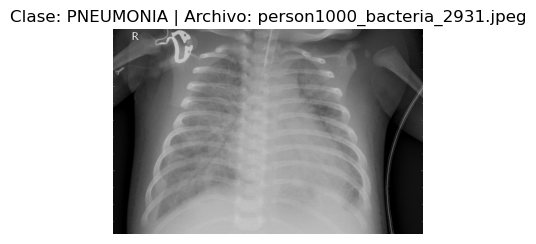

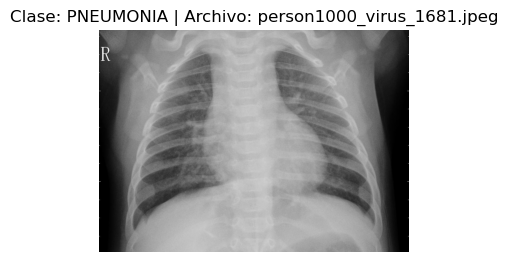

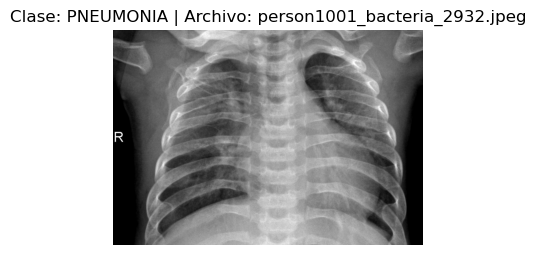

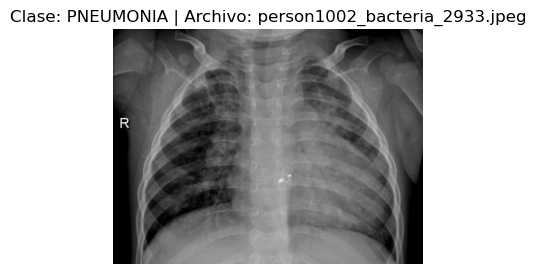

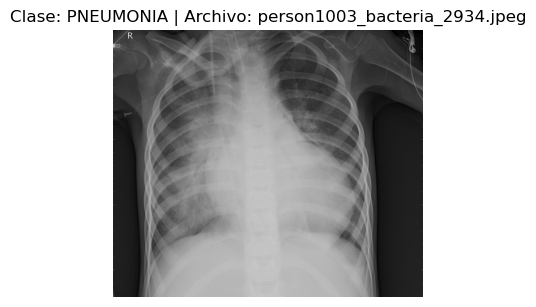

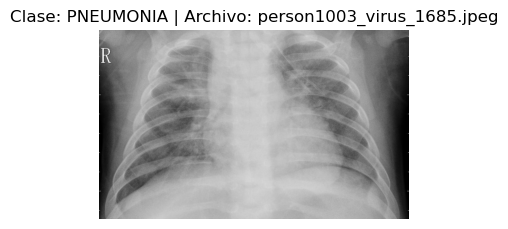

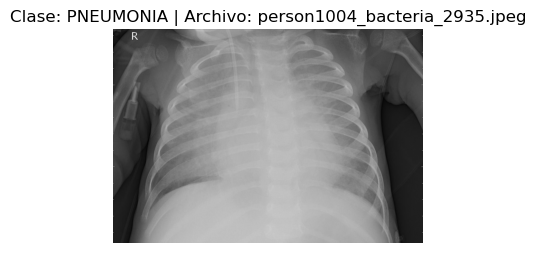

In [174]:
for archivo in archivos:
    ruta_completa = os.path.join(ruta_clase, archivo)
    
    # 1. Cargamos la imagen para mostrarla
    img_visual = cv2.imread(ruta_completa, 0)
    
    # 2. Visualización
    plt.figure(figsize=(4, 4))
    plt.imshow(img_visual, cmap='gray')
    plt.title(f"Clase: {clase} | Archivo: {archivo}")
    plt.axis('off')
    plt.show() # Esto es lo que hace que aparezcan las imágenes
    
    # 3. EXTRAENOS LAS CARACTERISTICAS DE LA RUTA COMPLETA
    datos_img = extraer_caracteristicas(ruta_completa)
    datos_img['Clase'] = clase
    lista_datos.append(datos_img)

#### ¿Qué es una radiografía de tórax?
Es una prueba médica de diagnóstico por imagen que utiliza una pequeña dosis de radiación ionizante para producir imágenes de las estructuras internas del pecho. Nos permite ver los pulmones, el corazón, los vasos sanguíneos, las vías respiratorias y los huesos de la caja torácica. Es la herramienta principal para detectar anomalías como infecciones, derrames pleurales o incluso problemas cardíacos.

#### ¿Qué es la neumonía?
Es una infección inflamatoria de los pulmones que hace que los alvéolos los saquitos de aire se llenen de líquido o pus. Esto provoca tos, fiebre, dificultad para respirar y dolor en el pecho. En una radiografía, se suele ver como manchas opacas o "densidades" blanquecinas en áreas que normalmente deberían verse oscuras llenas de aire.

#### ¿Cuál es el objetivo del dataset?
El objetivo principal es proporcionar una base de datos etiquetada para entrenar y evaluar modelos de inteligencia artificial específicamente redes neuronales convolucionales capaces de clasificar automáticamente imágenes médicas. Queremos que el modelo aprenda a distinguir con alta precisión si una radiografía muestra un pulmón sano o uno con neumonía, funcionando como una herramienta de apoyo al diagnóstico para los médicos.

#### ¿Qué clases contiene?
El dataset suele dividirse principalmente en dos clases:

NORMAL: Radiografías de pacientes que no presentan signos de infección pulmonar.

PNEUMONIA: Radiografías de pacientes que presentan hallazgos consistentes con esta enfermedad ya sea de origen bacteriano o viral

#### ¿Por qué este conjunto de datos requiere un proceso ETL antes del entrenamiento de un modelo?
Necesitamos hacer un proceso de Extracción, Transformación y Carga ETL porque las imágenes en bruto no están listas para que una IA las entienda directamente:

#### Extracción: Primero sacamos las imágenes de las carpetas originales.

 Transformación: Aquí es donde ocurre la magia necesaria. Las imágenes tienen tamaños, brillos y contrastes distintos. Tenemos que redimensionarlas todas al mismo tamaño, normalizar los valores de los píxeles para que la red neuronal converja más rápido, convertir a escala de grises y, muy importante, aplicar técnicas de aumento de datos data augmentation si el dataset está desequilibrado.

 Carga: Finalmente, las preparamos en lotes batches organizados para que el modelo pueda leerlas de forma eficiente durante el entrenamiento. Sin este paso, el modelo sería incapaz de encontrar patrones consistentes porque habría demasiado "ruido" y variabilidad entre los datos.